Telescope Pupil Shape: (256, 256)
Masking Pupil Shape: (256, 256)
P2V of example defocus:  358.3200364453046  nm error
Max Test Aberration: 2.106263044754337, Min Test Aberration: -2.106263044754337
Max Defocus: 1.73173365959386, Min Defocus: -1.7319450915772043
Max Combined Aberration: 3.834613792614662, Min Combined Aberration: -2.52648021221135


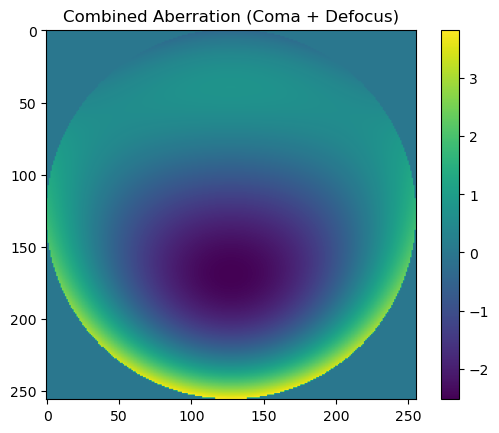

Defocus P2V Error: 7.166400728906092e-07 meters
Scale 2: P2V error: 6.9273575023421285 rad, 1.1025231890624758 waves, defocus distance: 13994.908389652417 microns
Defocus P2V Error: 3.583200364453046e-07 meters
Scale 1: P2V error: 3.4636787511710643 rad, 0.5512615945312379 waves, defocus distance: 6997.454194826209 microns
Max Pupil Phase before subtraction: 2.8662629205102936, Min Pupil Phase: -1.802455429012866


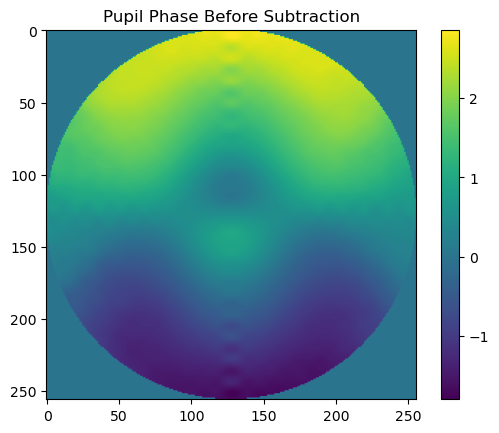

Max Med Subtracted Phase: 2.3477257714833115, Min Med Subtracted Phase: -2.3209925780398484


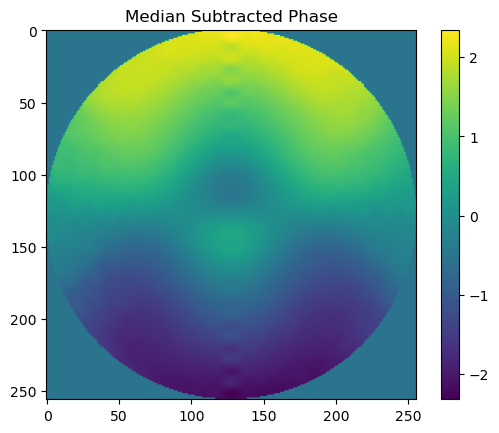

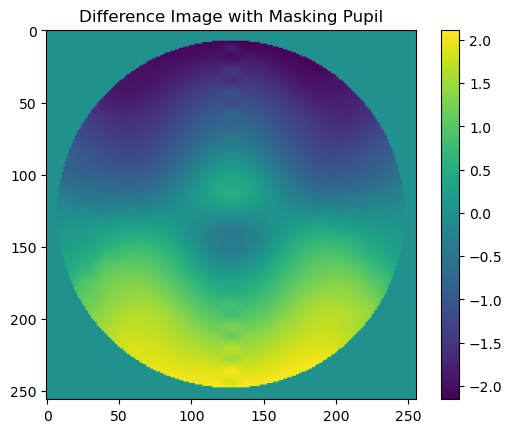

Median error of 0.0 radians.
Median error in nanometers: 0.0 nm
RMS error: 1.2330435401017923 radians


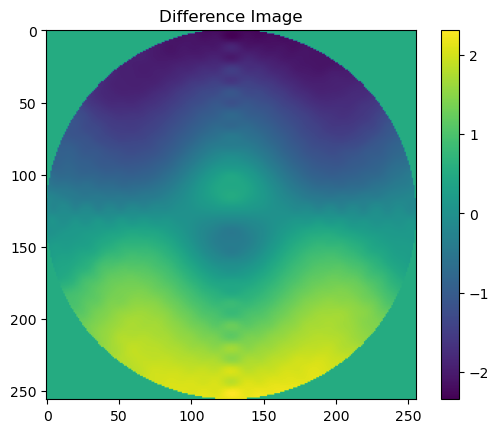

In [2]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
from image_sharpening import FocusDiversePhaseRetrieval, ft_rev, mft_rev, InstrumentConfiguration
from skimage.transform import resize

# Constants
pupil_size = 10.12e-3
small_pupil_size = 9.5e-3 
focal_length = 500e-3
wavelength = 650e-9
grid_size = 256
q = 16
num_airy = 16
f = focal_length
D = pupil_size
dx_list = [2.0071, 2.0071]

# Create the pupil grid
pupil_grid = make_pupil_grid(grid_size, pupil_size)

# Create the focal grid
focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=wavelength)

# Aperture setup
aperture = make_circular_aperture(pupil_size)
telescope_pupil = aperture(pupil_grid).reshape(grid_size, grid_size)  # Reshape to (256, 256)

small_aperture = make_circular_aperture(small_pupil_size)
masking_pupil = small_aperture(pupil_grid).reshape(grid_size, grid_size)  # Reshape to (256, 256)

# Debugging: Print shapes
print(f"Telescope Pupil Shape: {telescope_pupil.shape}")
print(f"Masking Pupil Shape: {masking_pupil.shape}")

def phase_to_m(phase, wv):
    """ Converts phase in radians to meters. """
    return phase * wv / (2 * np.pi)

def p_to_delta(P, f, D):
    """ Converts P (the peak to valley error in the pupil plane) induced by a delta (the longitudinal distance) offset. """
    print(f"Defocus P2V Error: {P} meters")  # Debugging
    return 8 * P * (f/D)**2

def delta_to_p(delta, f, D):
    """ Converts delta (longitudinal defocus distance) to P2V. """
    print(f"Defocus delta: {delta} meters")  # Debugging
    return -1 * delta / (8 * (f/D)**2)

def propagate_image(defocus_phase, test_ab, telescope_pupil, wavelength):
    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
    combined_phase = (test_ab + defocus_phase).reshape(grid_size, grid_size)  # Reshape phase to (256, 256)
    pupil_field = telescope_pupil * np.exp(complex(0, 1) * combined_phase)  # Both arrays are now (256, 256)
    wavefront = Wavefront(pupil_field, wavelength)
    focal_field = prop_p2f.forward(wavefront)
    focal_intensity = np.abs(focal_field.electric_field.reshape(focal_grid.shape))**2
    return focal_intensity

def calculate_defocus_params(example_defocus, scale, f, D):
    """
    Calculates P2V error and defocus distance for given defocus phase and scale.
    """
    defocus_phase = example_defocus * scale
    p2v_radians = np.max(defocus_phase) - np.min(defocus_phase)
    p2v_m = phase_to_m(p2v_radians, 650e-9)  # Phase converted to meters
    delta = p_to_delta(p2v_m, f, D)
    
    
    delta = delta if scale > 0 else -1 * delta  # Adjust delta sign based on scale
    return p2v_radians, delta

def generate_defocus_lists(example_defocus, scales, f, D, test_ab, telescope_pupil, wavelength):
    """
    Generates defocus lists and calculates PSF for each scale.
    """
    psf_list = []
    distance_list = []

    # Ensure the shapes are compatible
    example_defocus = example_defocus.reshape(telescope_pupil.shape)
    test_ab = test_ab.reshape(telescope_pupil.shape)

    # Calculate no-defocus image
    no_defocus_phase = np.zeros_like(example_defocus)
    no_defocus_image = propagate_image(no_defocus_phase, test_ab, telescope_pupil, wavelength)
    psf_list.append(no_defocus_image)

    for scale in scales:
        # Calculate P2V error and defocus distance
        p2v_radians, delta = calculate_defocus_params(example_defocus, scale, f, D)
        print(f'Scale {scale}: P2V error: {p2v_radians} rad, {p2v_radians/(2*np.pi)} waves, defocus distance: {delta*1e6} microns')
        defocus_image = propagate_image(example_defocus * scale, test_ab, telescope_pupil, wavelength)
        psf_list.append(defocus_image)
        distance_list.append(delta * 1e6)  # Defocus distance in microns

    return psf_list, distance_list, dx_list

def run_focus_diverse_phase_retrieval_v2(scales=[2, 1], test_ab_scale=0.75):
    # 1. Set up pupil size, focal length, and pupil grid
    pupil_grid = make_pupil_grid(grid_size, pupil_size)
    aperture = make_circular_aperture(pupil_size)
    telescope_pupil = aperture(pupil_grid).reshape(grid_size, grid_size)  # Reshape to (256, 256)
    small_aperture = make_circular_aperture(small_pupil_size)
    masking_pupil = small_aperture(pupil_grid).reshape(grid_size, grid_size)  # Reshape to (256, 256)

    # 2. Build wavefront and focal grid
    wavefront = Wavefront(telescope_pupil, wavelength=wavelength)
    focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=wavelength)

    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)

    # 3. Define aberrations (Coma + Defocus)
    influence_functions = make_zernike_basis(256, pupil_size, pupil_grid)

    # Coma (Zernike mode 6) and Defocus (Zernike mode 3)
    test_ab = test_ab_scale * influence_functions[6].reshape(grid_size, grid_size)  # Coma aberration
    example_defocus = influence_functions[3].reshape(grid_size, grid_size)  # Defocus
    # Remind ourselves what this example defocus looks like

    plt.imshow(example_defocus)
    p2v_radians = (np.max(example_defocus) - np.min(example_defocus))
    p2v_m = phase_to_m(p2v_radians, 650e-9)
    print('P2V of example defocus: ', p2v_m*1e9, ' nm error')
    
    scale=1
    defocus_phase = example_defocus * scale

    # Debugging: Print the raw values of the test aberration and defocus before combining
    print(f"Max Test Aberration: {np.max(test_ab)}, Min Test Aberration: {np.min(test_ab)}")
    print(f"Max Defocus: {np.max(example_defocus)}, Min Defocus: {np.min(example_defocus)}")

    # 4. Combine aberrations 
    
    combined_aberration = (test_ab + defocus_phase)

    # Debugging: Check the combined aberration (Coma + Defocus)
    print(f"Max Combined Aberration: {np.max(combined_aberration)}, Min Combined Aberration: {np.min(combined_aberration)}")
    plt.imshow(combined_aberration)
    plt.colorbar()
    plt.title("Combined Aberration (Coma + Defocus)")
    plt.show()

    # 5. Generate PSFs with natural combined aberrations
    psf_list, distance_list, dx_list = generate_defocus_lists(example_defocus, scales, f, D, combined_aberration, telescope_pupil, wavelength)

    # 6. Perform phase retrieval loop
    mp = FocusDiversePhaseRetrieval(psf_list, wavelength, dx_list, distance_list)
    for i in range(200):
        psf00 = mp.step()

    seal_params = {'image_dx': 2.0071, # 
               'efl': focal_length*1e3, # SEAL effective focal length, mm
               'wavelength': 0.65, # SEAL center wavelength, microns
                'pupil_size': pupil_size*1e3, # Keck entrance pupil diameter
                    }
    conf = InstrumentConfiguration(seal_params)

    raw_pupil_phase = np.angle(mft_rev(psf00, conf))
    
    pupil_phase = resize(raw_pupil_phase, (256, 256)) * telescope_pupil

    # Print and visualize the pupil phase before subtraction
    print(f"Max Pupil Phase before subtraction: {np.max(pupil_phase)}, Min Pupil Phase: {np.min(pupil_phase)}")
    plt.imshow(pupil_phase)
    plt.colorbar()
    plt.title("Pupil Phase Before Subtraction")
    plt.show()

    # 7. Subtract the median phase and debug
    med_subtracted = pupil_phase - np.median(pupil_phase[masking_pupil > 0])

    print(f"Max Med Subtracted Phase: {np.max(med_subtracted)}, Min Med Subtracted Phase: {np.min(med_subtracted)}")
    plt.imshow(med_subtracted)
    plt.colorbar()
    plt.title("Median Subtracted Phase")
    plt.show()

    # 8. Calculate the difference image and visualize
    pupil_image_phase = wavefront.phase.reshape(pupil_phase.shape)
    difference_image = pupil_image_phase - med_subtracted

    # 9. Check
    check_error_region = (pupil_image_phase - med_subtracted)[masking_pupil > 0]


    # Visualize difference image
    plt.imshow(difference_image * masking_pupil)
    plt.colorbar()
    plt.title("Difference Image with Masking Pupil")
    plt.show()

    # 9. Calculate the error in the masked region
    median_error = np.median(check_error_region)
    print(f'Median error of {median_error} radians.')

    # 10. Convert median error to nanometers
    nm_med = phase_to_m(median_error, wavelength) * 1e9
    print(f'Median error in nanometers: {nm_med} nm')

    # 11. Calculate RMS error
    valid_phase_values = med_subtracted[telescope_pupil > 0]
    mean_phase = np.mean(valid_phase_values)
    rms_error = np.sqrt(np.mean((valid_phase_values - mean_phase) ** 2))
    print(f"RMS error: {rms_error} radians")

    return {"pupil_phase": pupil_phase, "difference_image": difference_image, "psf_list": psf_list, "p2v_error": np.max(pupil_phase) - np.min(pupil_phase), "rms_error": rms_error, "nm_med": nm_med}


scales = [2, 1]
test_ab_scale = 0.75  # You can adjust this to ensure it correctly reflects the aberrations
results = run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale)

# Visualize difference image
plt.imshow(results["difference_image"])
plt.colorbar()
plt.title("Difference Image")
plt.show()



